# Foundation 4: Seaborn — Statistical Visualisation
### Data Science for Chartered Accountants — Pre-Module

---

## What is this notebook about?

**Seaborn** is built on top of Matplotlib and makes beautiful statistical charts with less code. While Matplotlib gives you full control (every pixel), Seaborn gives you **smarter defaults and statistical features** out of the box.

This notebook assumes:
- ✅ `00a_numpy_basics.ipynb` completed
- ✅ `00b_pandas_basics.ipynb` completed
- ✅ `00c_matplotlib_basics.ipynb` completed
- ❌ No prior Seaborn knowledge required

## What will you learn?
1. Seaborn vs Matplotlib — when to use which
2. Themes and palettes
3. Distribution plots: `histplot`, `kdeplot`, `boxplot`, `violinplot`
4. Categorical plots: `barplot`, `countplot`, `stripplot`
5. Relational plots: `scatterplot`, `lineplot`
6. Heatmap — correlation matrices
7. Pairplot — multi-variable relationships
8. Combining Seaborn + Matplotlib for fine-tuning
9. Bridge to accounting use-cases

---

> **Seaborn is to Matplotlib what a well-formatted MIS report is to raw trial balance data — same information, presented far more clearly.**

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

%matplotlib inline

# Set global theme
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

print('Seaborn version:', sns.__version__)
print('Ready!')

Seaborn version: 0.13.2
Ready!


---
## Section 1: Seaborn vs Matplotlib — Choose the Right Tool

| Task | Use Matplotlib | Use Seaborn |
|------|---------------|-------------|
| Custom annotated chart | ✅ | |
| Financial dashboard layout | ✅ | |
| Distribution analysis | | ✅ |
| Correlation heatmap | | ✅ |
| Outlier detection (boxplot) | | ✅ |
| Group comparison (barplot with CI) | | ✅ |
| Pairwise scatter matrix | | ✅ |

**Good news**: Seaborn returns Matplotlib Axes objects — so you can always add Matplotlib customisation on top of Seaborn charts.

---
## Section 2: Themes and Colour Palettes

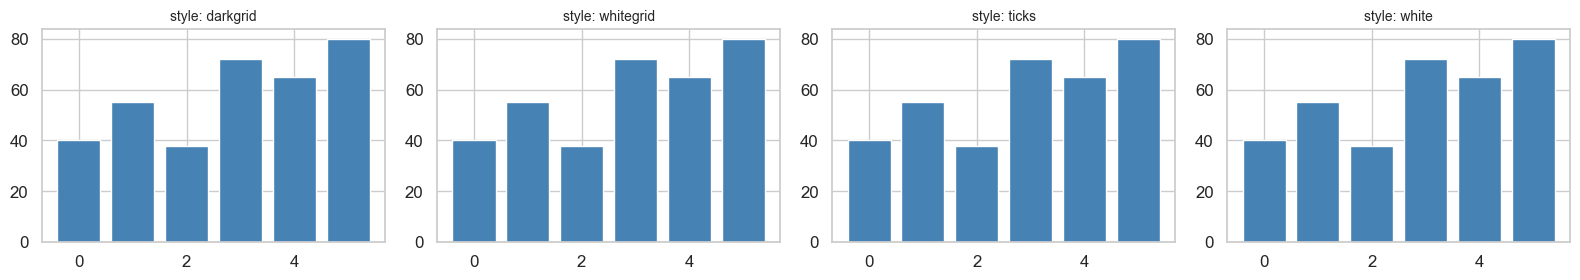

In [2]:
# ── Available styles ──────────────────────────────────────────────────────────
# 'darkgrid', 'whitegrid', 'dark', 'white', 'ticks'
# 'whitegrid' is cleanest for reports

styles = ['darkgrid', 'whitegrid', 'ticks', 'white']
x = np.arange(6)
y = [40, 55, 38, 72, 65, 80]

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for i, style in enumerate(styles):
    with sns.axes_style(style):
        axes[i].bar(x, y, color='steelblue')
        axes[i].set_title(f'style: {style}', fontsize=10)
plt.tight_layout()
plt.show()

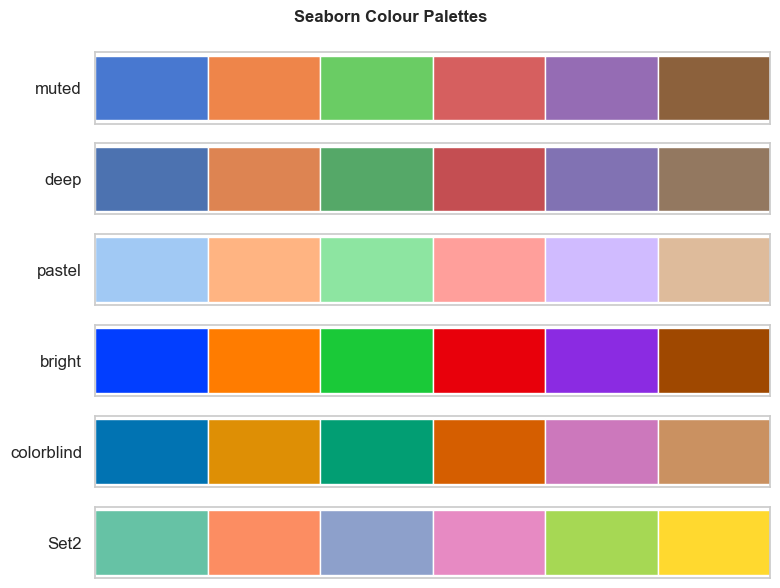

In [3]:
# ── Colour palettes ───────────────────────────────────────────────────────────
palettes = ['muted', 'deep', 'pastel', 'bright', 'colorblind', 'Set2']

fig, axes = plt.subplots(len(palettes), 1, figsize=(8, 6))
for ax, pal in zip(axes, palettes):
    colours = sns.color_palette(pal, 6)
    for j, c in enumerate(colours):
        ax.barh(0, 1, left=j, color=c)
    ax.set_yticks([0])
    ax.set_yticklabels([pal])
    ax.set_xticks([])
    ax.set_xlim(0, 6)

plt.suptitle('Seaborn Colour Palettes', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Recommendation: 'muted' or 'colorblind' for professional reports

---
## Section 3: Distribution Plots

In [4]:
# Create a salary dataset
np.random.seed(42)
salary_data = pd.DataFrame({
    'department': np.repeat(['Accounts', 'Audit', 'Tax', 'Finance'], 25),
    'salary'    : np.concatenate([
        np.random.normal(52000, 8000,  25),
        np.random.normal(48000, 6000,  25),
        np.random.normal(65000, 12000, 25),
        np.random.normal(75000, 15000, 25),
    ]),
    'grade'     : np.random.choice(['A', 'B', 'C'], 100),
})
salary_data['salary'] = salary_data['salary'].clip(30000, 1_50_000).round(-3)
print('Dataset shape:', salary_data.shape)
salary_data.head()

Dataset shape: (100, 3)


,department,salary,grade
0,Accounts,56000.0,A
1,Accounts,51000.0,B
2,Accounts,57000.0,A
3,Accounts,64000.0,A
4,Accounts,50000.0,C


/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_17021/4054635048.py:17: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


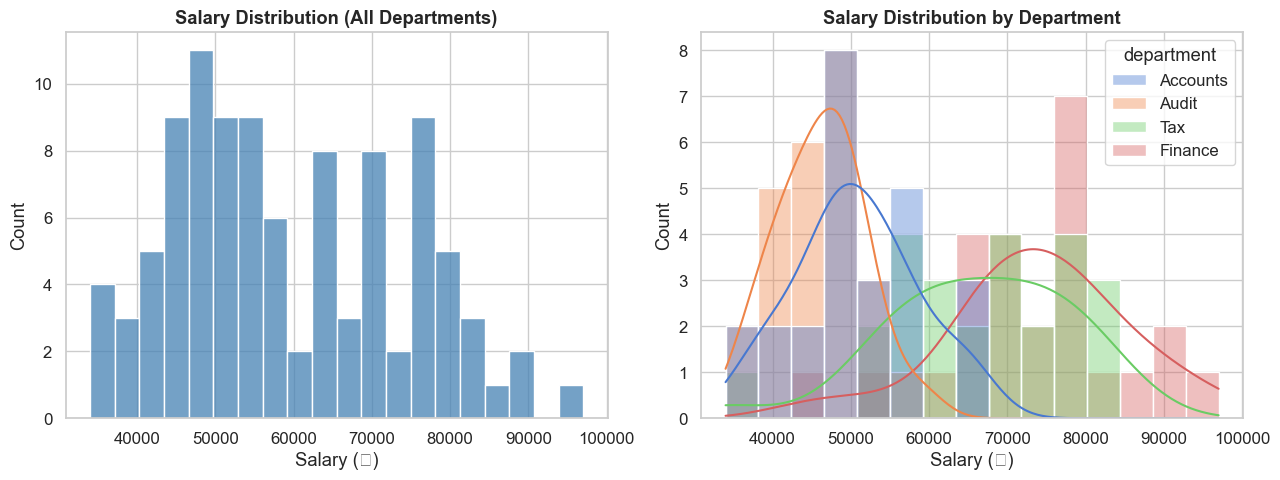

In [5]:
# ── sns.histplot — histogram with optional KDE overlay ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Basic histogram
sns.histplot(salary_data['salary'], bins=20, ax=axes[0], color='steelblue')
axes[0].set_title('Salary Distribution (All Departments)', fontweight='bold')
axes[0].set_xlabel('Salary (₹)')

# With KDE + by department
sns.histplot(
    data=salary_data, x='salary', hue='department',
    kde=True, bins=15, alpha=0.4, ax=axes[1]
)
axes[1].set_title('Salary Distribution by Department', fontweight='bold')
axes[1].set_xlabel('Salary (₹)')

plt.tight_layout()
plt.show()

/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_17021/4109426178.py:16: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


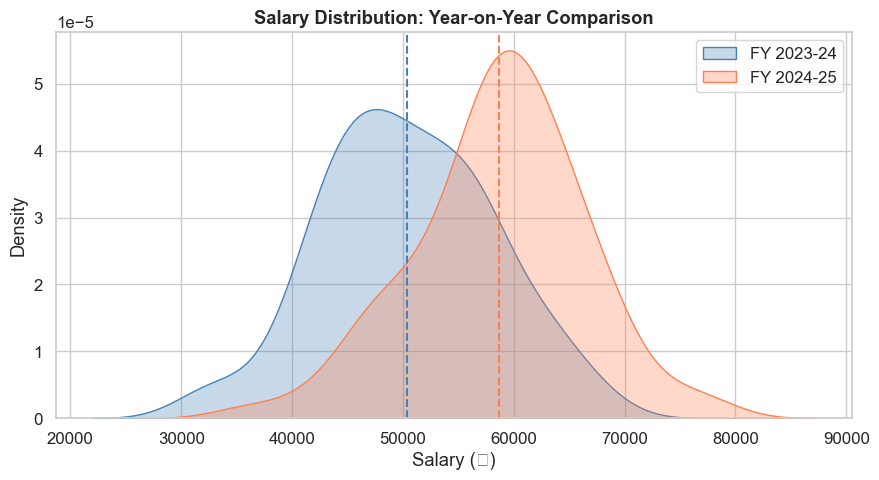

FY24 mean: ₹50,396  |  FY25 mean: ₹58,652


In [6]:
# ── sns.kdeplot — smooth density curve ───────────────────────────────────────
# Useful for comparing two distributions (e.g., last year vs this year)
np.random.seed(1)
prev_year = np.random.normal(50000, 8000, 80)
this_year = np.random.normal(58000, 9000, 80)

fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(prev_year, label='FY 2023-24', fill=True, alpha=0.3, color='steelblue')
sns.kdeplot(this_year, label='FY 2024-25', fill=True, alpha=0.3, color='coral')
ax.axvline(prev_year.mean(), color='steelblue', linestyle='--', linewidth=1.5)
ax.axvline(this_year.mean(), color='coral',    linestyle='--', linewidth=1.5)
ax.set_title('Salary Distribution: Year-on-Year Comparison', fontweight='bold')
ax.set_xlabel('Salary (₹)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()
print(f'FY24 mean: ₹{prev_year.mean():,.0f}  |  FY25 mean: ₹{this_year.mean():,.0f}')

/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_17021/3901900851.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=salary_data, x='department', y='salary',
/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_17021/3901900851.py:23: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


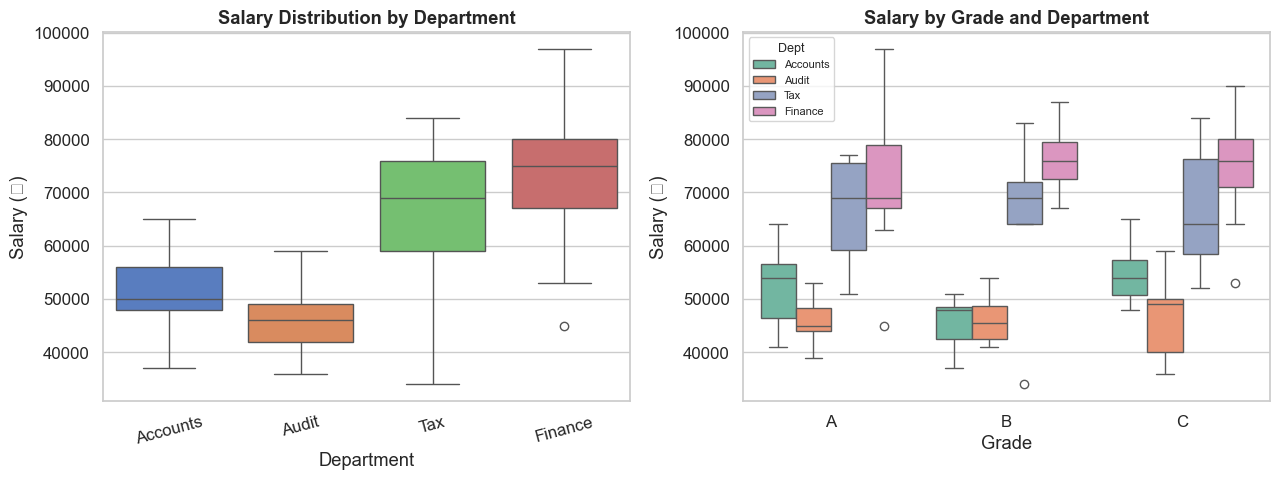

In [7]:
# ── sns.boxplot — detect outliers, compare medians ───────────────────────────
# The box = interquartile range (Q1 to Q3)
# The line = median; the whiskers = 1.5 × IQR; dots = outliers

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# By department
sns.boxplot(data=salary_data, x='department', y='salary',
            palette='muted', ax=axes[0])
axes[0].set_title('Salary Distribution by Department', fontweight='bold')
axes[0].set_xlabel('Department')
axes[0].set_ylabel('Salary (₹)')
axes[0].tick_params(axis='x', rotation=15)

# By grade, hue by department
sns.boxplot(data=salary_data, x='grade', y='salary',
            hue='department', palette='Set2', ax=axes[1])
axes[1].set_title('Salary by Grade and Department', fontweight='bold')
axes[1].set_xlabel('Grade')
axes[1].set_ylabel('Salary (₹)')
axes[1].legend(title='Dept', fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.show()

/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_17021/326856158.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_17021/326856158.py:13: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


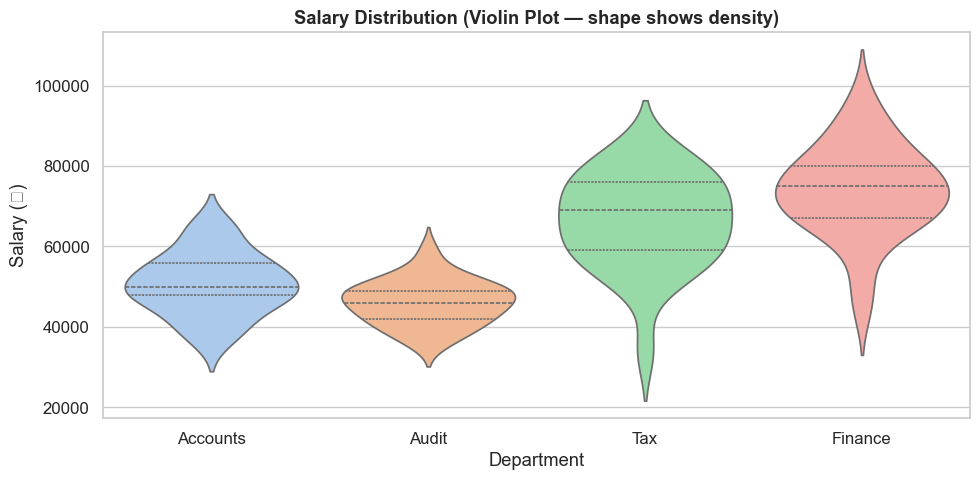

In [8]:
# ── sns.violinplot — combines box + KDE in one ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

sns.violinplot(
    data=salary_data, x='department', y='salary',
    palette='pastel', inner='quartile',    # inner='box' or 'quartile' or 'point'
    ax=ax
)
ax.set_title('Salary Distribution (Violin Plot — shape shows density)', fontweight='bold')
ax.set_xlabel('Department')
ax.set_ylabel('Salary (₹)')

plt.tight_layout()
plt.show()

---
## Section 4: Categorical Plots

/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_17021/3790605044.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=salary_data, x='department', y='salary',
/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_17021/3790605044.py:22: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


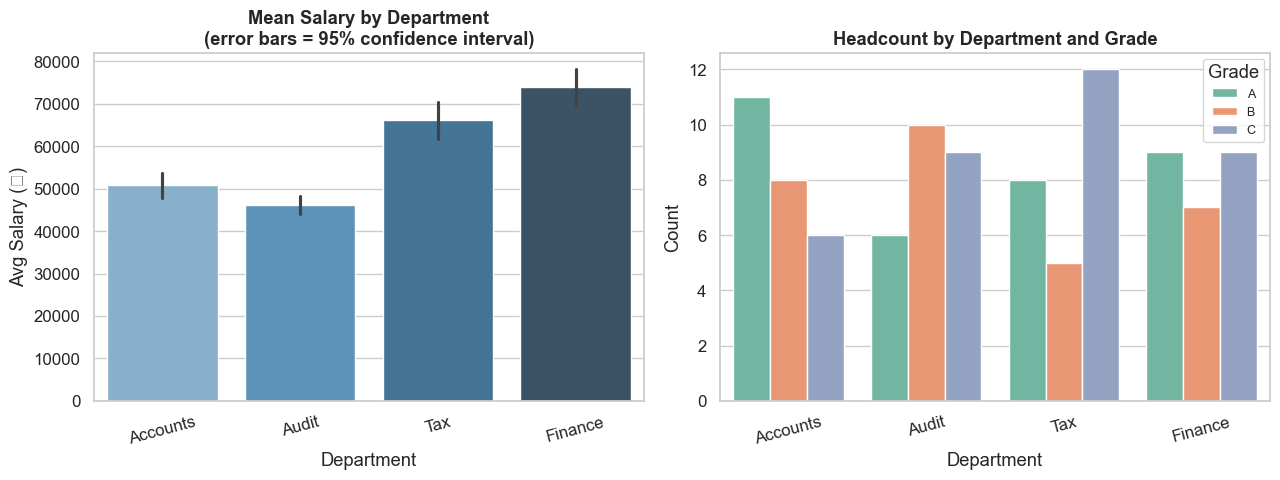

In [9]:
# ── sns.barplot — shows mean ± confidence interval ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Average salary by department with error bars (95% CI)
sns.barplot(data=salary_data, x='department', y='salary',
            palette='Blues_d', estimator='mean', errorbar='ci',
            ax=axes[0])
axes[0].set_title('Mean Salary by Department\n(error bars = 95% confidence interval)', fontweight='bold')
axes[0].set_xlabel('Department')
axes[0].set_ylabel('Avg Salary (₹)')
axes[0].tick_params(axis='x', rotation=15)

# ── sns.countplot — count of records per category ────────────────────────────
sns.countplot(data=salary_data, x='department', hue='grade',
              palette='Set2', ax=axes[1])
axes[1].set_title('Headcount by Department and Grade', fontweight='bold')
axes[1].set_xlabel('Department')
axes[1].set_ylabel('Count')
axes[1].legend(title='Grade', fontsize=9)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_17021/3746947156.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=salary_data, x='department', y='salary',
/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_17021/3746947156.py:16: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


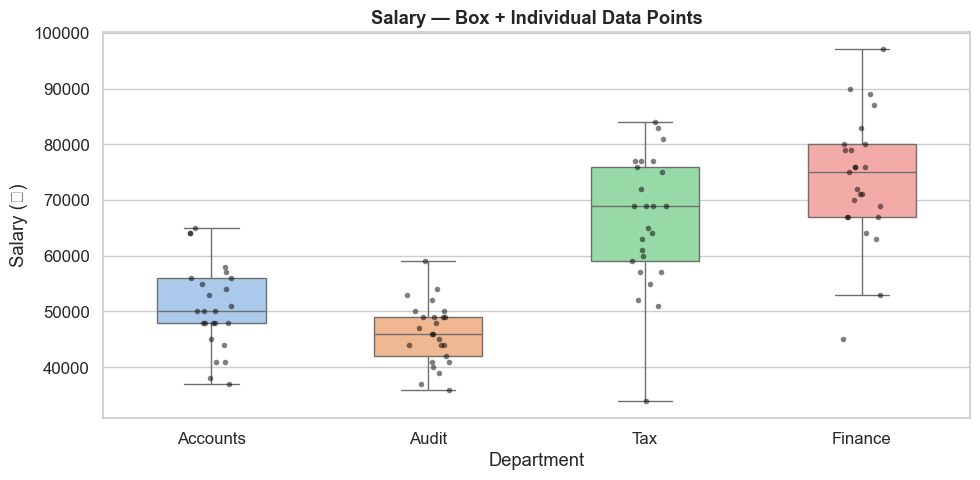

In [10]:
# ── sns.stripplot / swarmplot — show ALL data points ─────────────────────────
# Useful when n is small — you see every individual value

fig, ax = plt.subplots(figsize=(10, 5))

# Box under the strip (overlay technique)
sns.boxplot(data=salary_data, x='department', y='salary',
            palette='pastel', ax=ax, width=0.5, fliersize=0)
sns.stripplot(data=salary_data, x='department', y='salary',
              color='black', alpha=0.5, size=4, jitter=True, ax=ax)

ax.set_title('Salary — Box + Individual Data Points', fontweight='bold')
ax.set_xlabel('Department')
ax.set_ylabel('Salary (₹)')

plt.tight_layout()
plt.show()

---
## Section 5: Relational Plots — Trends and Relationships

/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_17021/3244243274.py:27: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


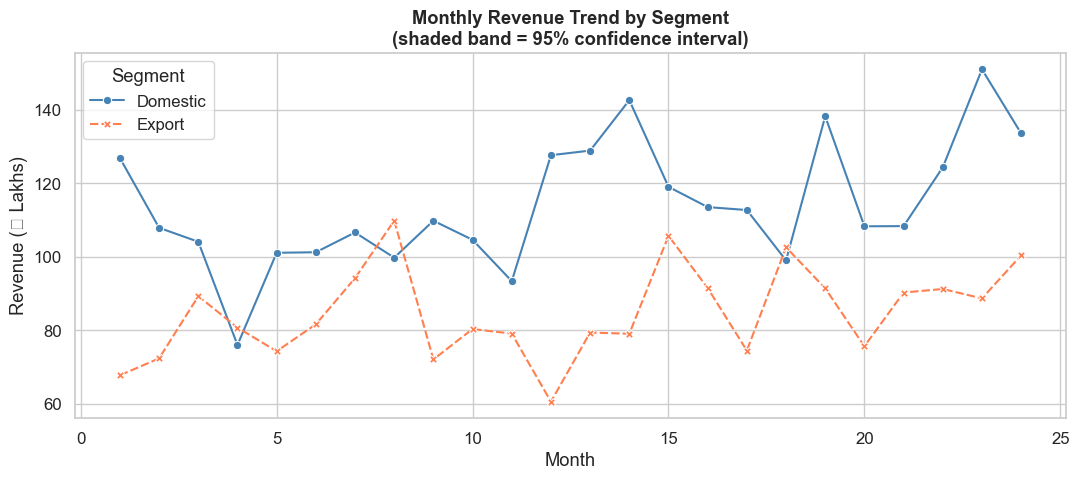

In [11]:
# Create a multi-year revenue dataset
np.random.seed(3)
trend_data = pd.DataFrame({
    'month'    : list(range(1, 25)) * 2,
    'revenue'  : np.concatenate([
        np.random.normal(100, 15, 24) + np.linspace(0, 30, 24),
        np.random.normal(80,  12, 24) + np.linspace(0, 20, 24),
    ]),
    'segment'  : ['Domestic'] * 24 + ['Export'] * 24,
})

# ── sns.lineplot — line with confidence band ──────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

sns.lineplot(
    data=trend_data, x='month', y='revenue',
    hue='segment', style='segment',
    markers=True, dashes=True,
    palette=['steelblue', 'coral'],
    ax=ax
)
ax.set_title('Monthly Revenue Trend by Segment\n(shaded band = 95% confidence interval)', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (₹ Lakhs)')
ax.legend(title='Segment')

plt.tight_layout()
plt.show()

/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_17021/2325755079.py:29: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


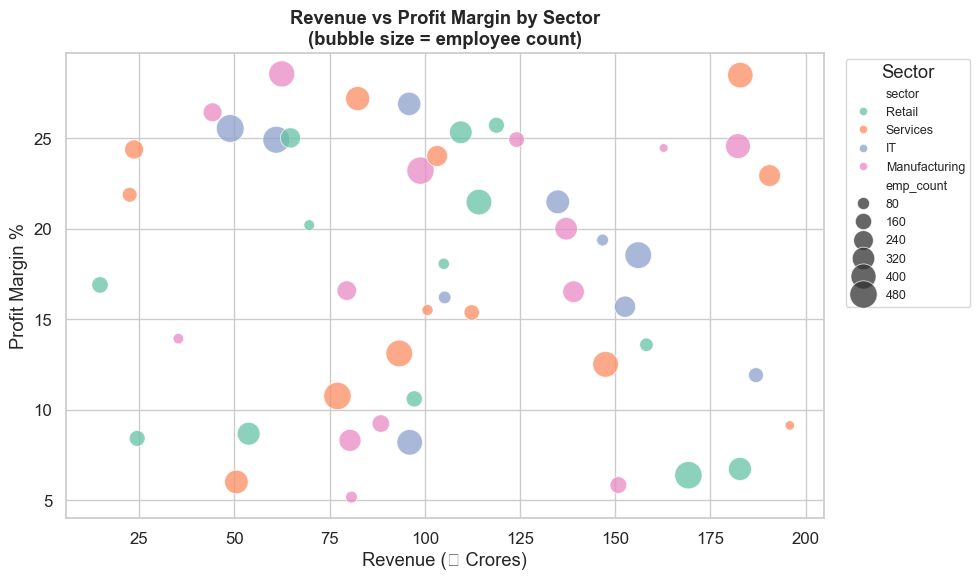

In [12]:
# ── sns.scatterplot — relationships between two numeric variables ─────────────
np.random.seed(7)
company_data = pd.DataFrame({
    'revenue_cr'  : np.random.uniform(10, 200, 50),
    'emp_count'   : np.random.randint(20, 500, 50),
    'profit_margin': np.random.uniform(5, 30, 50),
    'sector'      : np.random.choice(['Manufacturing', 'Services', 'Retail', 'IT'], 50),
})

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=company_data,
    x='revenue_cr',
    y='profit_margin',
    hue='sector',          # different colour per sector
    size='emp_count',      # bubble size = employee count
    sizes=(40, 400),
    alpha=0.75,
    palette='Set2',
    ax=ax
)

ax.set_title('Revenue vs Profit Margin by Sector\n(bubble size = employee count)', fontweight='bold')
ax.set_xlabel('Revenue (₹ Crores)')
ax.set_ylabel('Profit Margin %')
ax.legend(title='Sector', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

---
## Section 6: Heatmap — Correlation Analysis

In [13]:
# Create a financial metrics dataset
np.random.seed(42)
n = 60
revenue    = np.random.uniform(50, 500, n)

fin_metrics = pd.DataFrame({
    'Revenue'      : revenue,
    'EBITDA'       : revenue * np.random.uniform(0.10, 0.25, n) + np.random.randn(n) * 5,
    'Net_Profit'   : revenue * np.random.uniform(0.04, 0.12, n) + np.random.randn(n) * 3,
    'Working_Cap'  : revenue * np.random.uniform(0.15, 0.35, n) + np.random.randn(n) * 8,
    'Debt'         : revenue * np.random.uniform(0.20, 0.60, n) + np.random.randn(n) * 10,
    'Tax_Outgo'    : revenue * np.random.uniform(0.02, 0.06, n) + np.random.randn(n) * 2,
    'Employees'    : (revenue * np.random.uniform(0.5, 2.0, n)).astype(int),
})

# Compute correlation matrix
corr_matrix = fin_metrics.corr().round(2)
print('Correlation matrix:')
print(corr_matrix)

Correlation matrix:
             Revenue  EBITDA  Net_Profit  Working_Cap  Debt  Tax_Outgo  \
Revenue         1.00    0.85        0.84         0.89  0.86       0.85   
EBITDA          0.85    1.00        0.72         0.80  0.70       0.72   
Net_Profit      0.84    0.72        1.00         0.74  0.78       0.65   
Working_Cap     0.89    0.80        0.74         1.00  0.73       0.80   
Debt            0.86    0.70        0.78         0.73  1.00       0.73   
Tax_Outgo       0.85    0.72        0.65         0.80  0.73       1.00   
Employees       0.84    0.69        0.72         0.74  0.65       0.64   

             Employees  
Revenue           0.84  
EBITDA            0.69  
Net_Profit        0.72  
Working_Cap       0.74  
Debt              0.65  
Tax_Outgo         0.64  
Employees         1.00  


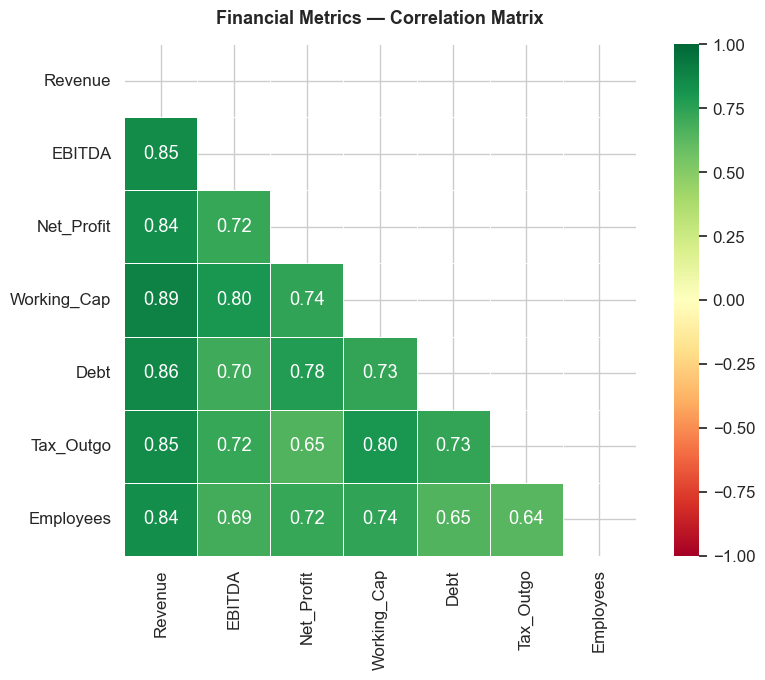


Top correlated pairs (|corr| > 0.7):
  EBITDA ↔ Revenue: 0.85
  Net_Profit ↔ Revenue: 0.84
  Working_Cap ↔ Revenue: 0.89
  Debt ↔ Revenue: 0.86
  Tax_Outgo ↔ Revenue: 0.85
  Employees ↔ Revenue: 0.84
  Revenue ↔ EBITDA: 0.85
  Net_Profit ↔ EBITDA: 0.72
  Working_Cap ↔ EBITDA: 0.80
  Tax_Outgo ↔ EBITDA: 0.72
  Revenue ↔ Net_Profit: 0.84
  EBITDA ↔ Net_Profit: 0.72
  Working_Cap ↔ Net_Profit: 0.74
  Debt ↔ Net_Profit: 0.78
  Employees ↔ Net_Profit: 0.72
  Revenue ↔ Working_Cap: 0.89
  EBITDA ↔ Working_Cap: 0.80
  Net_Profit ↔ Working_Cap: 0.74
  Debt ↔ Working_Cap: 0.73
  Tax_Outgo ↔ Working_Cap: 0.80
  Employees ↔ Working_Cap: 0.74
  Revenue ↔ Debt: 0.86
  Net_Profit ↔ Debt: 0.78
  Working_Cap ↔ Debt: 0.73
  Tax_Outgo ↔ Debt: 0.73
  Revenue ↔ Tax_Outgo: 0.85
  EBITDA ↔ Tax_Outgo: 0.72
  Working_Cap ↔ Tax_Outgo: 0.80
  Debt ↔ Tax_Outgo: 0.73
  Revenue ↔ Employees: 0.84
  Net_Profit ↔ Employees: 0.72
  Working_Cap ↔ Employees: 0.74


In [14]:
# ── sns.heatmap ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle (redundant)

sns.heatmap(
    corr_matrix,
    mask       = mask,
    annot      = True,         # show numbers in cells
    fmt        = '.2f',        # 2 decimal places
    cmap       = 'RdYlGn',    # Red=negative, Yellow=0, Green=positive
    vmin       = -1, vmax = 1,
    linewidths = 0.5,
    linecolor  = 'white',
    square     = True,
    ax         = ax
)

ax.set_title('Financial Metrics — Correlation Matrix', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# ── Reading the heatmap ───────────────────────────────────────────────────────
print('\nTop correlated pairs (|corr| > 0.7):')
for col in corr_matrix.columns:
    for row in corr_matrix.index:
        if row != col and abs(corr_matrix.loc[row, col]) > 0.7:
            print(f'  {row} ↔ {col}: {corr_matrix.loc[row, col]:.2f}')

---
## Section 7: Pairplot — Multi-variable Snapshot

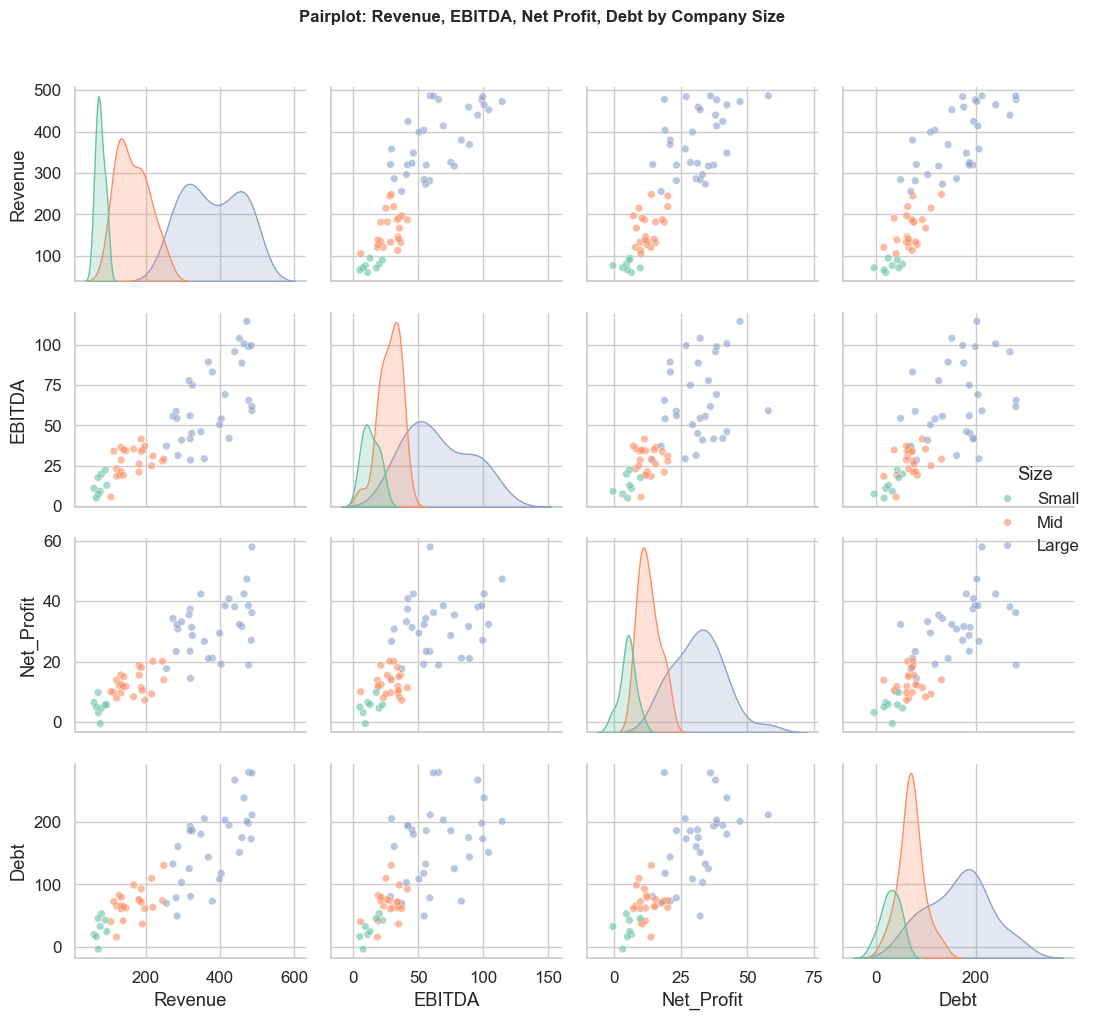

In [15]:
# Select 4 variables for pairplot (too many = slow)
subset = fin_metrics[['Revenue', 'EBITDA', 'Net_Profit', 'Debt']].copy()

# Add a categorical column for colour
subset['Size'] = pd.cut(fin_metrics['Revenue'],
                         bins=[0, 100, 250, 500],
                         labels=['Small', 'Mid', 'Large'])

g = sns.pairplot(
    subset,
    hue    = 'Size',
    palette = 'Set2',
    diag_kind = 'kde',       # diagonal: KDE instead of histogram
    plot_kws = dict(alpha=0.6, s=30)
)
g.figure.suptitle('Pairplot: Revenue, EBITDA, Net Profit, Debt by Company Size',
                   y=1.02, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 8: Combining Seaborn + Matplotlib

/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_17021/1825653084.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=expenses, x='department', y='claims',
/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_17021/1825653084.py:48: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_17021/1825653084.py:48: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarnin

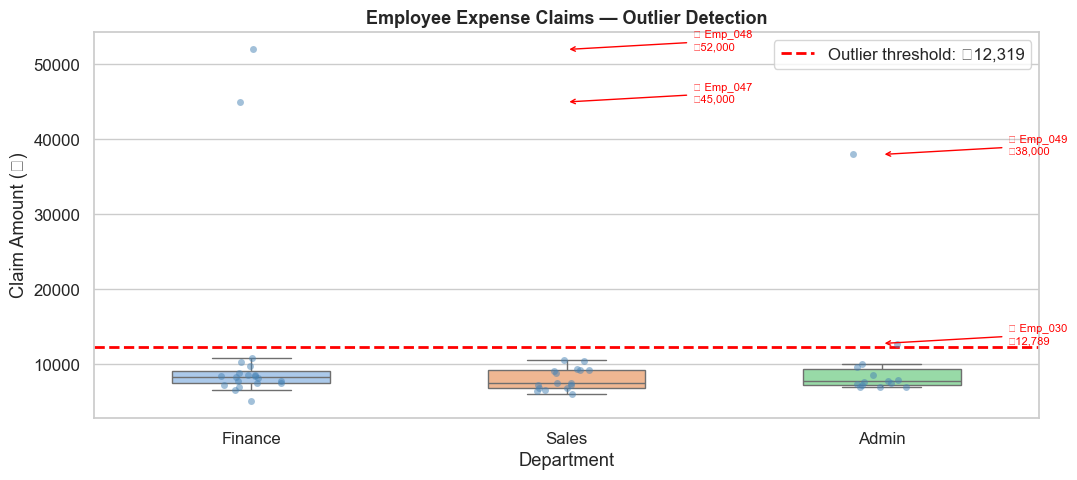


Outlier threshold: ₹12,319
Flagged employees:
employee department  claims
 Emp_030      Admin 12789.0
 Emp_047    Finance 45000.0
 Emp_048    Finance 52000.0
 Emp_049      Admin 38000.0


In [16]:
# Seaborn creates the chart — Matplotlib adds fine-tuning on top

# Expense anomaly detection (high-salary outlier analysis)
np.random.seed(10)
expenses = pd.DataFrame({
    'employee'  : [f'Emp_{i:03d}' for i in range(50)],
    'department': np.random.choice(['Sales', 'Finance', 'Admin'], 50),
    'claims'    : np.concatenate([
        np.random.normal(8000, 2000, 47),
        [45000, 52000, 38000]            # 3 outliers
    ])
})
expenses['claims'] = expenses['claims'].clip(500, 60_000).round(0)

# Calculate outlier threshold (Q3 + 1.5 × IQR)
Q1, Q3 = expenses['claims'].quantile(0.25), expenses['claims'].quantile(0.75)
IQR    = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

fig, ax = plt.subplots(figsize=(11, 5))

# Seaborn: box + strip
sns.boxplot(data=expenses, x='department', y='claims',
            palette='pastel', width=0.5, fliersize=0, ax=ax)
sns.stripplot(data=expenses, x='department', y='claims',
              color='steelblue', alpha=0.5, size=5, jitter=True, ax=ax)

# Matplotlib: add the outlier threshold line
ax.axhline(upper_bound, color='red', linestyle='--', linewidth=2,
           label=f'Outlier threshold: ₹{upper_bound:,.0f}')

# Highlight the actual outlier points
outliers = expenses[expenses['claims'] > upper_bound]
dept_pos = {'Sales': 0, 'Finance': 1, 'Admin': 2}
for _, row in outliers.iterrows():
    x_pos = dept_pos[row['department']]
    ax.annotate(f"⚠ {row['employee']}\n₹{row['claims']:,.0f}",
                xy=(x_pos, row['claims']),
                xytext=(x_pos + 0.4, row['claims']),
                fontsize=8, color='red',
                arrowprops=dict(arrowstyle='->', color='red'))

ax.set_title('Employee Expense Claims — Outlier Detection', fontsize=13, fontweight='bold')
ax.set_xlabel('Department')
ax.set_ylabel('Claim Amount (₹)')
ax.legend()

plt.tight_layout()
plt.show()

print(f'\nOutlier threshold: ₹{upper_bound:,.0f}')
print('Flagged employees:')
print(outliers[['employee', 'department', 'claims']].to_string(index=False))

---
## Section 9: Accounting Bridge — Monthly Expense Heatmap

/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_17021/4022606796.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '18.2' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  expense_matrix.loc['Dec'] = expense_matrix.loc['Dec'] * 1.4  # year-end spike
/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_17021/4022606796.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '51.8' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  expense_matrix.loc['Dec'] = expense_matrix.loc['Dec'] * 1.4  # year-end spike
/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_17021/4022606796.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '54.599999999999994

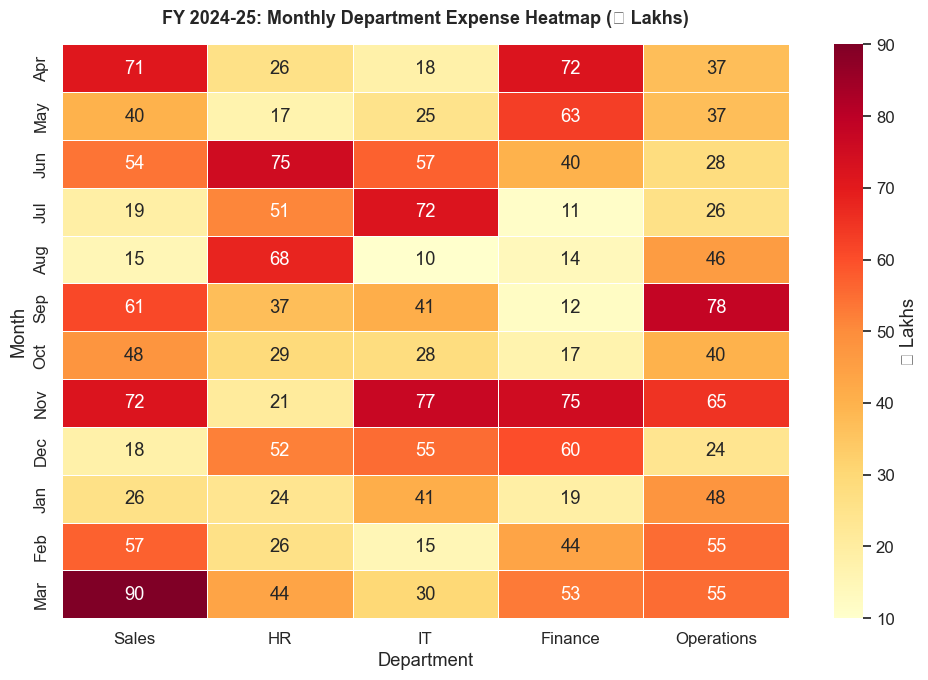


Highest spend: Sales in Mar — ₹90L


In [17]:
# Monthly expenses by department — useful for MIS reports
np.random.seed(5)
months = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep',
          'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar']
depts  = ['Sales', 'HR', 'IT', 'Finance', 'Operations']

expense_matrix = pd.DataFrame(
    np.random.randint(10, 80, size=(12, 5)),
    index   = months,
    columns = depts
)

# Add some variance for realism
expense_matrix.loc['Dec'] = expense_matrix.loc['Dec'] * 1.4  # year-end spike
expense_matrix.loc['Mar'] = expense_matrix.loc['Mar'] * 1.3  # year-end close
expense_matrix = expense_matrix.round(0).astype(int)

fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(
    expense_matrix,
    annot      = True,
    fmt        = 'd',
    cmap       = 'YlOrRd',   # light=low, red=high spend
    linewidths = 0.5,
    linecolor  = 'white',
    cbar_kws   = {'label': '₹ Lakhs'},
    ax         = ax
)

ax.set_title('FY 2024-25: Monthly Department Expense Heatmap (₹ Lakhs)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Department')
ax.set_ylabel('Month')

plt.tight_layout()
plt.show()

print('\nHighest spend: {dept} in {month} — ₹{val}L'.format(
    dept  = expense_matrix.stack().idxmax()[1],
    month = expense_matrix.stack().idxmax()[0],
    val   = expense_matrix.stack().max()
))

---
## Section 10: Quick Reference Summary

```python
import seaborn as sns

# Theme setup (do once at start of notebook)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# Distributions
sns.histplot(data=df, x='col', hue='group', bins=20, kde=True)
sns.kdeplot(data=df,  x='col', hue='group', fill=True, alpha=0.3)
sns.boxplot(data=df,  x='group', y='col', palette='muted')
sns.violinplot(data=df, x='group', y='col', inner='quartile')

# Categorical
sns.barplot(data=df,   x='group', y='col', estimator='mean', errorbar='ci')
sns.countplot(data=df, x='group', hue='subgroup')
sns.stripplot(data=df, x='group', y='col', jitter=True, alpha=0.5)

# Relational
sns.scatterplot(data=df, x='col1', y='col2', hue='group', size='col3')
sns.lineplot(data=df,    x='col1', y='col2', hue='group')

# Matrix / heatmap
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1)

# Multi-variable
sns.pairplot(df, hue='category', diag_kind='kde')

# Seaborn + Matplotlib
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(..., ax=ax)       # seaborn draws the chart
ax.axhline(threshold, ...)    # matplotlib adds annotations
plt.title('...')
plt.tight_layout()
plt.show()
```

### Seaborn vs Matplotlib recap:

| Use Seaborn for | Use Matplotlib for |
|---|---|
| Distribution analysis | Custom layout / positioning |
| Group comparisons | Precise annotations |
| Correlation heatmaps | Mixed chart types in one figure |
| Statistical confidence bands | Saving with exact dpi/size |

---
## Practice Exercises

1. Create a boxplot comparing invoice amounts across 4 different vendors. Identify which vendor has the most outliers.

2. Plot a histogram showing the distribution of GST amounts in a 100-row invoice dataset. Overlay the KDE curve.

3. Build a heatmap showing the correlation between: Revenue, PAT, EBITDA, Total Assets, Debt for 30 companies.

4. Create a countplot showing the number of transactions per month, colour-coded by transaction type (Credit / Debit).

5. Create a scatter plot of Days Sales Outstanding (DSO) vs Revenue for 25 customers. Use `hue` to show if the customer is in good standing or overdue.

/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_17021/1983584827.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=invoice_df, x='vendor', y='amount', palette='Set2', ax=ax)
/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_17021/1983584827.py:22: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


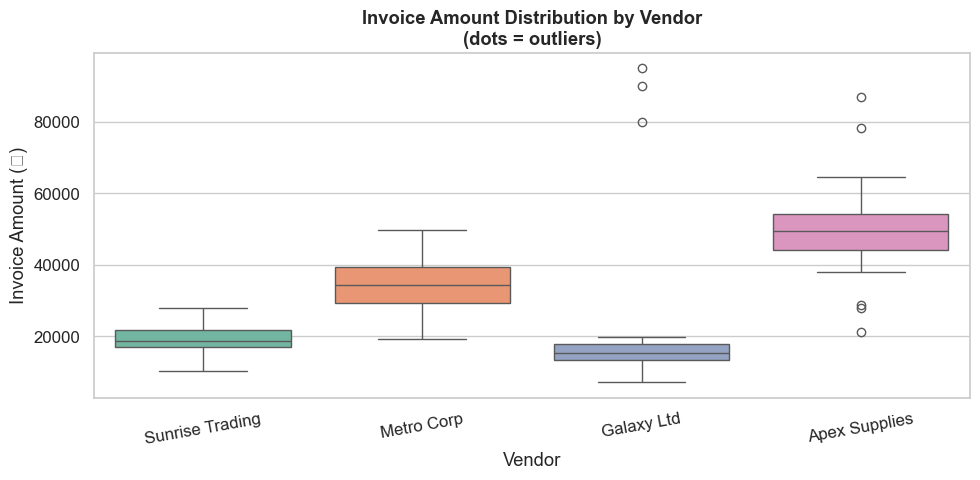


Invoices above 1.5×IQR per vendor:
  Apex Supplies: 2 outliers (threshold ₹69,321)
  Galaxy Ltd: 3 outliers (threshold ₹24,594)
  Metro Corp: 0 outliers (threshold ₹54,402)
  Sunrise Trading: 0 outliers (threshold ₹28,936)


In [18]:
# ── Exercise Solutions ─────────────────────────────────────────────────────────

# Exercise 1: Invoice boxplot by vendor
np.random.seed(42)
invoice_df = pd.DataFrame({
    'vendor' : np.repeat(['Sunrise Trading', 'Metro Corp', 'Galaxy Ltd', 'Apex Supplies'], 30),
    'amount' : np.concatenate([
        np.random.normal(20000, 5000,  30),
        np.random.normal(35000, 8000,  30),
        np.concatenate([np.random.normal(15000, 3000, 27), [80000, 90000, 95000]]),  # outliers
        np.random.normal(50000, 15000, 30),
    ])
})
invoice_df['amount'] = invoice_df['amount'].clip(1000, 2_00_000).round(0)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=invoice_df, x='vendor', y='amount', palette='Set2', ax=ax)
ax.set_title('Invoice Amount Distribution by Vendor\n(dots = outliers)', fontweight='bold')
ax.set_xlabel('Vendor')
ax.set_ylabel('Invoice Amount (₹)')
ax.tick_params(axis='x', rotation=10)
plt.tight_layout()
plt.show()

print('\nInvoices above 1.5×IQR per vendor:')
for vendor, group in invoice_df.groupby('vendor'):
    Q1 = group['amount'].quantile(0.25)
    Q3 = group['amount'].quantile(0.75)
    ub = Q3 + 1.5 * (Q3 - Q1)
    outlier_count = (group['amount'] > ub).sum()
    print(f'  {vendor}: {outlier_count} outliers (threshold ₹{ub:,.0f})')